In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# DATA CLEANING


In [2]:
df = pd.read_excel("Online Retail.xlsx")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [3]:
df.shape

(541909, 8)

In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df['Description'] = df['Description'].fillna('Not Available')

In [8]:
# -1 Unavailable Customer ids
df['CustomerID'] = df['CustomerID'].fillna(-1)

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [11]:
df.duplicated().sum()

np.int64(5268)

In [12]:
# Remove exact duplicate records
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(536641, 8)

# FEATURING

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Date'] = df['InvoiceDate'].dt.date
df['Time'] = df['InvoiceDate'].dt.time
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()


In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December


In [16]:
(df['Quantity'] <= 0).sum()

np.int64(10587)

In [17]:
df[df['Quantity'] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,2010-12-01,09:41:00,2010,12,December
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,2010-12-01,09:49:00,2010,12,December
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,2010-12-01,10:24:00,2010,12,December
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom,2010-12-01,12:38:00,2010,12,December


In [18]:
(df['UnitPrice'] <= 0).sum()

np.int64(2512)

In [19]:
df[df['UnitPrice'] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName
622,536414,22139,Not Available,56,2010-12-01 11:52:00,0.0,-1.0,United Kingdom,2010-12-01,11:52:00,2010,12,December
1970,536545,21134,Not Available,1,2010-12-01 14:32:00,0.0,-1.0,United Kingdom,2010-12-01,14:32:00,2010,12,December
1971,536546,22145,Not Available,1,2010-12-01 14:33:00,0.0,-1.0,United Kingdom,2010-12-01,14:33:00,2010,12,December
1972,536547,37509,Not Available,1,2010-12-01 14:33:00,0.0,-1.0,United Kingdom,2010-12-01,14:33:00,2010,12,December
1987,536549,85226A,Not Available,1,2010-12-01 14:34:00,0.0,-1.0,United Kingdom,2010-12-01,14:34:00,2010,12,December
1988,536550,85044,Not Available,1,2010-12-01 14:34:00,0.0,-1.0,United Kingdom,2010-12-01,14:34:00,2010,12,December
2024,536552,20950,Not Available,1,2010-12-01 14:34:00,0.0,-1.0,United Kingdom,2010-12-01,14:34:00,2010,12,December
2025,536553,37461,Not Available,3,2010-12-01 14:35:00,0.0,-1.0,United Kingdom,2010-12-01,14:35:00,2010,12,December
2026,536554,84670,Not Available,23,2010-12-01 14:35:00,0.0,-1.0,United Kingdom,2010-12-01,14:35:00,2010,12,December
2406,536589,21777,Not Available,-10,2010-12-01 16:50:00,0.0,-1.0,United Kingdom,2010-12-01,16:50:00,2010,12,December


In [20]:
df['InvoiceNo'].astype(str).str.startswith('C').value_counts()

InvoiceNo
False    527390
True       9251
Name: count, dtype: int64

In [21]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01,08:28:00,2010,12,December
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,2010-12-01,08:28:00,2010,12,December
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,2010-12-01,08:34:00,2010,12,December


In [22]:
df.nlargest(10, 'Quantity')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,2011-12-09,09:15:00,2011,12,December
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,2011-01-18,10:01:00,2011,1,January
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom,2011-11-25,15:57:00,2011,11,November
74614,542504,37413,Not Available,5568,2011-01-28 12:03:00,0.00,-1.0,United Kingdom,2011-01-28,12:03:00,2011,1,January
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,2011-10-27,12:26:00,2011,10,October
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,2011-05-27,10:52:00,2011,5,May
220843,556231,85123A,?,4000,2011-06-09 15:04:00,0.00,-1.0,United Kingdom,2011-06-09,15:04:00,2011,6,June
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,2011-02-22,10:43:00,2011,2,February
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,2011-07-19,17:04:00,2011,7,July
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,2011-01-11,12:55:00,2011,1,January


In [23]:
df['Revenue'] = df['UnitPrice'] * df['Quantity']

In [24]:
df.nlargest(10, 'Revenue')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,2011-12-09,09:15:00,2011,12,December,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,2011-01-18,10:01:00,2011,1,January,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,2011-06-10,15:28:00,2011,6,June,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,-1.0,United Kingdom,2010-12-07,15:08:00,2010,12,December,13541.33
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,-1.0,United Kingdom,2011-08-12,14:50:00,2011,8,August,11062.06
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,2011-05-03,13:46:00,2011,5,May,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,2011-09-20,11:05:00,2011,9,September,7144.72
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,2011-01-11,12:55:00,2011,1,January,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,2011-04-18,13:20:00,2011,4,April,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,2011-10-27,12:11:00,2011,10,October,4992.00


In [25]:
df['IsCancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

df['IsCancelled'].value_counts()

IsCancelled
False    527390
True       9251
Name: count, dtype: int64

In [26]:
df[df['Quantity'] < 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Country']
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,17897.0,United Kingdom


In [27]:
df[df['UnitPrice'] <= 0][
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'CustomerID', 'Country']
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,Not Available,56,0.0,-1.0,United Kingdom
1970,536545,21134,Not Available,1,0.0,-1.0,United Kingdom
1971,536546,22145,Not Available,1,0.0,-1.0,United Kingdom
1972,536547,37509,Not Available,1,0.0,-1.0,United Kingdom
1987,536549,85226A,Not Available,1,0.0,-1.0,United Kingdom
1988,536550,85044,Not Available,1,0.0,-1.0,United Kingdom
2024,536552,20950,Not Available,1,0.0,-1.0,United Kingdom
2025,536553,37461,Not Available,3,0.0,-1.0,United Kingdom
2026,536554,84670,Not Available,23,0.0,-1.0,United Kingdom
2406,536589,21777,Not Available,-10,0.0,-1.0,United Kingdom


In [28]:
df['StockCode'].value_counts().head(30)

StockCode
85123A    2301
22423     2192
85099B    2156
47566     1720
20725     1626
84879     1489
22720     1469
22197     1468
21212     1367
22383     1328
20727     1323
22457     1272
23203     1260
POST      1256
22386     1245
22469     1232
22960     1221
21931     1211
22086     1194
22411     1192
20728     1185
22961     1177
22382     1177
23298     1175
22666     1173
22699     1128
23209     1126
82482     1124
22384     1121
22993     1099
Name: count, dtype: int64

In [29]:
df['Revenue'].describe()

count    536641.000000
mean         18.123861
std         380.656263
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [30]:
df['Revenue'].sum()

np.float64(9726006.954)

In [31]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Time,Year,Month,MonthName,Revenue,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,08:26:00,2010,12,December,20.34,False


In [32]:
# Gives us a clean dataset for sales/revenue analysis without destroying our original df.
sales_df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['IsCancelled'])
].copy()

sales_df['Revenue'] = sales_df['Quantity'] * sales_df['UnitPrice']

In [33]:
# We'll analyze returns separately instead of deleting useful information.
returns_df = df[df['IsCancelled']].copy()

In [34]:
print("Original:", df.shape)
print("Sales:", sales_df.shape)
print("Returns:", returns_df.shape)
print("Revenue:", sales_df['Revenue'].sum())
print("Orders:", sales_df['InvoiceNo'].nunique())
print("Units Sold:", sales_df['Quantity'].sum())

Original: (536641, 15)
Sales: (524878, 15)
Returns: (9251, 15)
Revenue: 10642110.804000001
Orders: 19960
Units Sold: 5572420


In [35]:
sales_df['Revenue'].sum()

np.float64(10642110.804000001)

In [36]:
sales_df['InvoiceNo'].nunique()

19960

In [37]:
sales_df['Quantity'].sum()

np.int64(5572420)

In [38]:
sales_df['Revenue'].sum() / sales_df['InvoiceNo'].nunique()

np.float64(533.171883967936)

In [39]:
monthly_sales = (
    sales_df.groupby(['Year','Month', 'MonthName'])['Revenue'].sum().reset_index().sort_values(['Year', 'Month'])
)
monthly_sales


,Year,Month,MonthName,Revenue
0,2010,12,December,821452.730
1,2011,1,January,689811.610
2,2011,2,February,522545.560
3,2011,3,March,716215.260
4,2011,4,April,536968.491
5,2011,5,May,769296.610
6,2011,6,June,760547.010
7,2011,7,July,718076.121
8,2011,8,August,757841.380
9,2011,9,September,1056435.192


<Axes: xlabel='MonthName'>

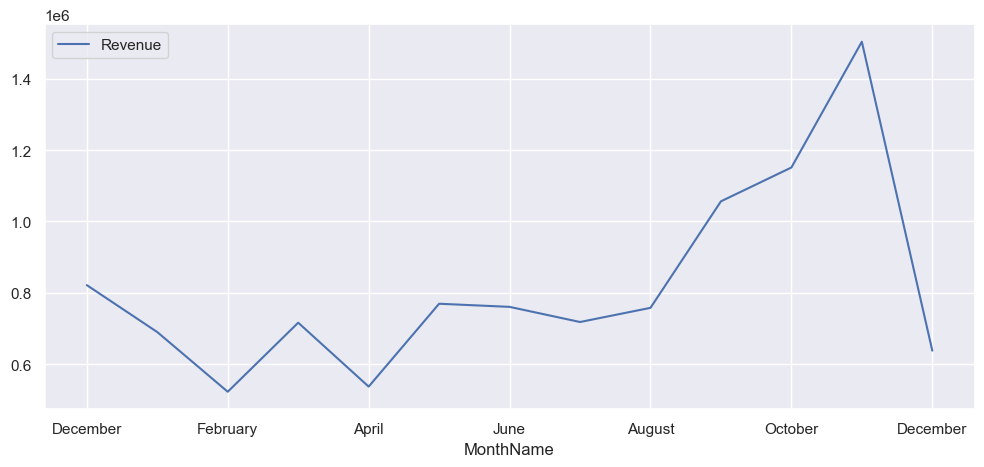

In [40]:
monthly_sales.plot(
    x='MonthName',
    y='Revenue',
    kind='line',
    figsize=(12,5)
)

In [41]:
monthly_orders = (
    sales_df.groupby(['Year', 'Month'])['InvoiceNo'].nunique().reset_index(name='Orders')
)
monthly_orders

,Year,Month,Orders
0,2010,12,1559
1,2011,1,1086
2,2011,2,1100
3,2011,3,1454
4,2011,4,1246
5,2011,5,1681
6,2011,6,1533
7,2011,7,1475
8,2011,8,1361
9,2011,9,1837


<Axes: xlabel='Month', ylabel='Orders'>

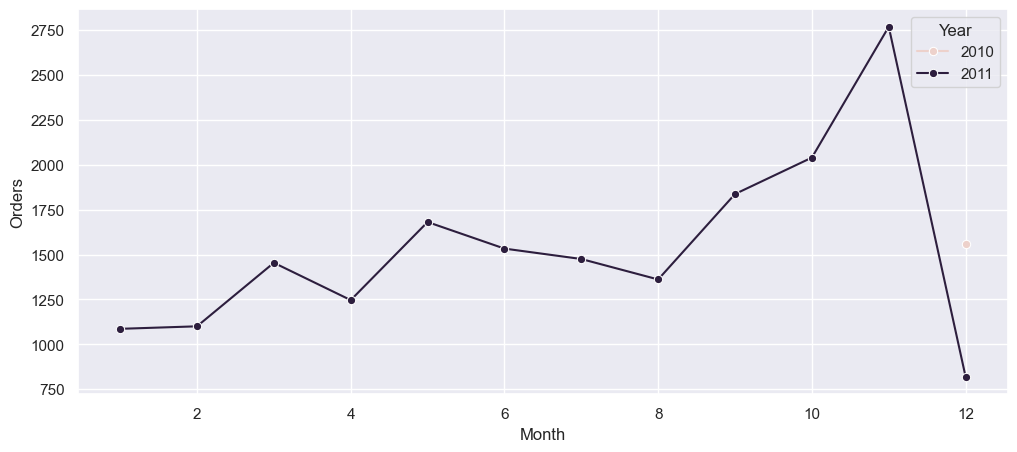

In [42]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_orders,
    x='Month',
    y='Orders',
    hue='Year',        # separate line per year
    marker='o'
)


In [43]:
sales_df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['InvoiceNo'].astype(str).str.startswith('C'))
].copy()

sales_df['Revenue'] = (
    sales_df['Quantity'] * sales_df['UnitPrice']
)

In [44]:
sales_df.shape

(524878, 15)

In [45]:
sales_df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Date           0
Time           0
Year           0
Month          0
MonthName      0
Revenue        0
IsCancelled    0
dtype: int64

In [46]:
sales_df.to_csv(
    'online_retail_clean.csv',
    index=False
)